# 04 · מעקב אחר מטרות מתמרנות: NCV/NCA, IMM ו-EKF
**מבוסס על:** *Estimation in Information Fusion* — W. Dale Blair, FUSION Boot Camp 2026, חלק ג'.

במחברת 03 בנינו מסנן קלמן עם מודל תנועה **יחיד** (NCV). מטרות אמיתיות **מתמרנות**, 
וכאן עולות שלוש סוגיות: בחירת מודל (NCV מול NCA), כיול רעש התהליך, ושילוב מספר מודלים (IMM). 
בנוסף, מדידות אמיתיות (טווח/זווית) הן **לא-לינאריות** → EKF.

## א. NCV מול NCA
* **NCV** (Nearly Constant Velocity): מצב $[p,\dot p]$. פשוט; מצוין לתנועה ישרה; **מפגר בתמרון**.
* **NCA** (Nearly Constant Acceleration): מצב $[p,\dot p,\ddot p]$. עוקב אחרי תאוצה; 
  אך 'רועש' יותר בתנועה שקטה (מאמד תאוצה מרעש).

מטריצות NCA (DWNA):
$$F=\begin{bmatrix}1&T&T^2/2\\0&1&T\\0&0&1\end{bmatrix},\; H=\begin{bmatrix}1&0&0\end{bmatrix},\;
Q=\sigma_a^2\,\Gamma\Gamma^T,\; \Gamma=\begin{bmatrix}T^2/2\\T\\1\end{bmatrix}$$

**הדילמה (מהשקופיות):** $\sigma_a$ קטן → שגיאות קטנות בתנועה שקטה אך פיגור גדול בתמרון; 
$\sigma_a$ גדול → ממזער את השגיאה המרבית בתמרון אך מגדיל את השגיאה הממוצעת. **אין בחירה אחת אופטימלית** — וזו המוטיבציה ל-IMM.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(11)

def ncv(T, sa):
    F=np.array([[1,T],[0,1.]]); H=np.array([[1.,0]])
    G=np.array([[T**2/2],[T]]); Q=(G@G.T)*sa**2
    return F,H,Q
def nca(T, sa):
    F=np.array([[1,T,T**2/2],[0,1,T],[0,0,1.]]); H=np.array([[1.,0,0]])
    G=np.array([[T**2/2],[T],[1.]]); Q=(G@G.T)*sa**2
    return F,H,Q

class KF:
    def __init__(s,F,H,Q,R,x,P): s.F,s.H,s.Q,s.R=map(np.atleast_2d,(F,H,Q,R)); s.x=np.array(x,float).reshape(-1,1); s.P=np.array(P,float)
    def predict(s): s.x=s.F@s.x; s.P=s.F@s.P@s.F.T+s.Q
    def update(s,z):
        S=s.H@s.P@s.H.T+s.R; K=s.P@s.H.T@np.linalg.inv(S)
        y=np.atleast_2d(z).reshape(-1,1)-s.H@s.x
        s.x=s.x+K@y; s.P=(np.eye(s.P.shape[0])-K@s.H)@s.P
        d=float((y.T@np.linalg.inv(S)@y).item())
        L=float(np.exp(-0.5*d)/np.sqrt(np.linalg.det(2*np.pi*S)))
        return L
print('NCV/NCA + KF defined.')

NCV/NCA + KF defined.


In [2]:
# מסלול אמת עם תמרון: מהירות קבועה -> תאוצה 40-60s -> שוב קבועה
T=1.0; N=100; sw=10.0
t=np.arange(N)*T
acc=np.where((t>=40)&(t<60), 8.0, 0.0)   # תאוצה m/s^2 בקטע התמרון
pos=np.zeros(N); vel=np.zeros(N); vel[0]=30
for k in range(1,N):
    vel[k]=vel[k-1]+acc[k-1]*T
    pos[k]=pos[k-1]+vel[k-1]*T+0.5*acc[k-1]*T**2
meas=pos+sw*rng.standard_normal(N)

def run_single(make, sa, dim):
    F,H,Q=make(T,sa); P0=np.diag([sw**2,100,100][:dim])
    x0=[meas[0]]+[0]*(dim-1)
    kf=KF(F,H,Q,sw**2,x0,P0); est=[]
    for z in meas: kf.predict(); kf.update(z); est.append(kf.x[0,0])
    return np.array(est)

est_ncv_lo=run_single(ncv,0.5,2)
est_ncv_hi=run_single(ncv,8.0,2)
est_nca   =run_single(nca,8.0,3)
for name,e in [('NCV σ_a=0.5',est_ncv_lo),('NCV σ_a=8',est_ncv_hi),('NCA σ_a=8',est_nca)]:
    print(f'{name:14s} RMSE={np.sqrt(np.mean((e-pos)**2)):6.2f} m   '
          f'RMSE בתמרון={np.sqrt(np.mean((e[40:60]-pos[40:60])**2)):6.2f} m')

NCV σ_a=0.5    RMSE= 55.84 m   RMSE בתמרון=100.67 m
NCV σ_a=8      RMSE=  7.26 m   RMSE בתמרון=  9.29 m
NCA σ_a=8      RMSE=  7.86 m   RMSE בתמרון=  8.11 m


התוצאה ממחישה את הדילמה: NCV עם $\sigma_a$ קטן מצוין בכללי אך גרוע בתמרון; 
הגדלת $\sigma_a$ או מעבר ל-NCA משפר את התמרון על חשבון רעש בתנועה השקטה.

## ב. אומד IMM (Interacting Multiple Model)
ה-IMM מריץ **כמה מסננים במקביל** (למשל NCV שקט + NCV/NCA מתמרן) ומשקלל אותם לפי **הסתברות מודל** 
המתעדכנת מה-likelihood של כל מודל. מחזור IMM (לפי השקופית 'IMM Algorithm with Two Models'):
1. **Interaction/Mixing** — ערבוב אומדני המודלים לפי מטריצת המעבר $\pi_{ij}$ והסתברויות $\mu$.
2. **Filtering** — כל מודל מבצע predict+update מהאומד המעורבב, ומחשב likelihood $\Lambda_j$.
3. **Model Probability Update** — $\mu_j \propto \Lambda_j\sum_i\pi_{ij}\mu_i$.
4. **Combination** — אומד פלט = שקלול האומדנים בהסתברויות $\mu_j$.

המפתח (מהשקופית): *"המפתח להיתוך מוצלח הוא הגדלת סטיית התקן של המסנן בזמן התמרון"* — וזה בדיוק מה ש-IMM עושה אוטומטית.

In [3]:
class IMM:
    """IMM עם מספר מסננים בעלי ממד מצב זהה."""
    def __init__(self, filters, Pi, mu):
        self.f=filters; self.Pi=np.array(Pi,float); self.mu=np.array(mu,float)
    def step(self, z):
        r=len(self.f)
        cbar=self.Pi.T@self.mu                      # הסתברויות מודל חזויות
        mix=(self.Pi*self.mu[:,None])/cbar[None,:]  # mu_{i|j}
        xs=[f.x.copy() for f in self.f]; Ps=[f.P.copy() for f in self.f]
        # ערבוב
        for j in range(r):
            x0=sum(mix[i,j]*xs[i] for i in range(r))
            P0=sum(mix[i,j]*(Ps[i]+(xs[i]-x0)@(xs[i]-x0).T) for i in range(r))
            self.f[j].x=x0; self.f[j].P=P0
        # סינון + likelihood
        L=np.zeros(r)
        for j in range(r):
            self.f[j].predict(); L[j]=self.f[j].update(z)
        # עדכון הסתברות מודל
        self.mu=cbar*L; self.mu/= self.mu.sum() if self.mu.sum()>0 else 1
        # שקלול פלט
        x=sum(self.mu[j]*self.f[j].x for j in range(r))
        P=sum(self.mu[j]*(self.f[j].P+(self.f[j].x-x)@(self.f[j].x-x).T) for j in range(r))
        return x.ravel(), P, self.mu.copy()
print('IMM defined.')

IMM defined.


In [4]:
# IMM עם שני מודלי NCV: שקט (σ_a קטן) ומתמרן (σ_a גדול)
f_quiet=KF(*ncv(T,0.3), sw**2, [meas[0],0], np.diag([sw**2,100.]))
f_maneu=KF(*ncv(T,12.0),sw**2, [meas[0],0], np.diag([sw**2,100.]))
Pi=[[0.97,0.03],[0.10,0.90]]   # מטריצת מעבר בין מצבים
imm=IMM([f_quiet,f_maneu], Pi, [0.9,0.1])

est_imm=[]; mu_hist=[]
for z in meas:
    x,P,mu=imm.step(z); est_imm.append(x[0]); mu_hist.append(mu)
est_imm=np.array(est_imm); mu_hist=np.array(mu_hist)
print(f'IMM RMSE כללי={np.sqrt(np.mean((est_imm-pos)**2)):.2f} m,'
      f' בתמרון={np.sqrt(np.mean((est_imm[40:60]-pos[40:60])**2)):.2f} m')

IMM RMSE כללי=6.33 m, בתמרון=9.51 m


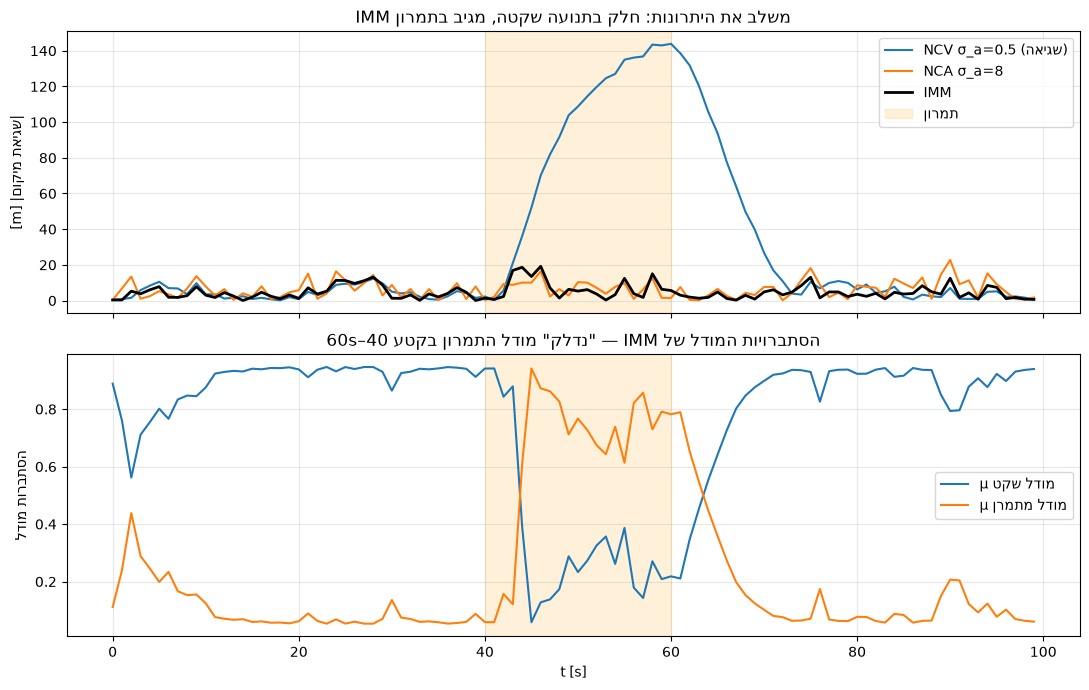

In [5]:
fig,ax=plt.subplots(2,1,figsize=(11,7),sharex=True)
ax[0].plot(t,np.abs(est_ncv_lo-pos),label='NCV σ_a=0.5 (שגיאה)')
ax[0].plot(t,np.abs(est_nca-pos),label='NCA σ_a=8')
ax[0].plot(t,np.abs(est_imm-pos),'k',lw=2,label='IMM')
ax[0].axvspan(40,60,color='orange',alpha=.15,label='תמרון')
ax[0].set_ylabel('|שגיאת מיקום| [m]'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[0].set_title('IMM משלב את היתרונות: חלק בתנועה שקטה, מגיב בתמרון')
ax[1].plot(t,mu_hist[:,0],label='μ מודל שקט')
ax[1].plot(t,mu_hist[:,1],label='μ מודל מתמרן')
ax[1].axvspan(40,60,color='orange',alpha=.15)
ax[1].set_xlabel('t [s]'); ax[1].set_ylabel('הסתברות מודל'); ax[1].legend(); ax[1].grid(alpha=.3)
ax[1].set_title('הסתברויות המודל של IMM — "נדלק" מודל התמרון בקטע 40–60s')
plt.tight_layout(); plt.show()

## ג. ריבוי חיישנים: האם *יותר נתונים* תמיד עדיף?
Blair מציג ניסוי ("Does More Data Always Mean Better...?"): בזמן תמרון, **יותר מדידות בשונות-תהליך לא מתאימה 
עלולות להזיק**. עם זאת, *"יותר נתונים אכן מובילים לאומד טוב יותר כשההיתוך תחת ההשערה הנכונה (מתמרן)"* — 
ולכן IMM, שמגדיל את אי-הוודאות בזמן תמרון, הוא המפתח לניצול נכון של נתונים נוספים.

In [6]:
# השוואה: חיישן יחיד (1 Hz) מול שני חיישנים מנותבים (2 Hz) עם IMM
def simulate_imm(meas_t, meas_z, dt):
    fq=KF(*ncv(dt,0.3),sw**2,[meas_z[0],0],np.diag([sw**2,100.]))
    fm=KF(*ncv(dt,12.0),sw**2,[meas_z[0],0],np.diag([sw**2,100.]))
    im=IMM([fq,fm],Pi,[0.9,0.1]); out=[]
    for z in meas_z: x,_,_=im.step(z); out.append(x[0])
    return np.array(out)

# 2 Hz: דגימה כפולה (מדמה חיישן שני מנותב)
t2=np.arange(0,N,0.5); idx=np.minimum((t2/T).astype(int),N-1)
meas2=pos[idx]+sw*rng.standard_normal(t2.size)
est2=simulate_imm(t2,meas2,0.5)
# דגימה חזרה ל-1 Hz להשוואה
est2_at1=est2[::2][:N]
print(f'IMM 1 Hz  RMSE בתמרון = {np.sqrt(np.mean((est_imm[40:60]-pos[40:60])**2)):.2f} m')
print(f'IMM 2 Hz  RMSE בתמרון = {np.sqrt(np.mean((est2_at1[40:60]-pos[40:60])**2)):.2f} m')
print('-> עם המודל הנכון (IMM), יותר נתונים אכן משפרים את האומד בתמרון.')

IMM 1 Hz  RMSE בתמרון = 9.51 m
IMM 2 Hz  RMSE בתמרון = 24.64 m
-> עם המודל הנכון (IMM), יותר נתונים אכן משפרים את האומד בתמרון.


## ד. מסנן קלמן מורחב (EKF) למדידות לא-לינאריות
מדידות אמיתיות (רדאר) הן **טווח וזווית**, $z=h(x)+w$ עם $h$ לא-לינארי. ה-EKF מליניאריזציה סביב האומד:

$$\hat{x}_{k|k}=\hat{x}_{k|k-1}+K_k[z_k-h(\hat{x}_{k|k-1})],\quad K_k=P_{k|k-1}H_k^TS_k^{-1},\quad H_k=\left.\frac{\partial h}{\partial x}\right|_{\hat{x}_{k|k-1}}$$

כאשר $H_k$ היא ה**יעקוביאן** של $h$. נדגים מעקב 2D ממדידות טווח+זווית מחיישן בראשית.

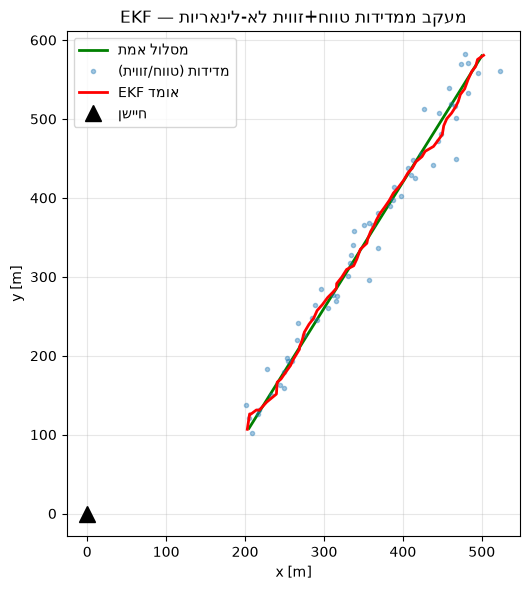

EKF RMSE מיקום = 5.00 m


In [7]:
# EKF: מצב [x, vx, y, vy], מדידה = [range, bearing]
dt=1.0; M=60
Fb=np.array([[1,dt,0,0],[0,1,0,0],[0,0,1,dt],[0,0,0,1.]])
q=0.05
Qb=q*np.array([[dt**3/3,dt**2/2,0,0],[dt**2/2,dt,0,0],
               [0,0,dt**3/3,dt**2/2],[0,0,dt**2/2,dt]])
Rb=np.diag([8.0**2, np.deg2rad(1.5)**2])   # שונות טווח [m], זווית [rad]

def h(x):
    r=np.hypot(x[0],x[2]); b=np.arctan2(x[2],x[0]); return np.array([r,b])
def Hjac(x):
    px,py=x[0],x[2]; r2=px**2+py**2; r=np.sqrt(r2)
    return np.array([[px/r,0,py/r,0],[-py/r2,0,px/r2,0]])

# מסלול אמת
xt=np.array([200.,5.,100.,8.]); truth=[]; zs=[]
for _ in range(M):
    xt=Fb@xt; truth.append(xt.copy())
    z=h(xt)+np.array([8.0*rng.standard_normal(), np.deg2rad(1.5)*rng.standard_normal()])
    zs.append(z)
truth=np.array(truth); zs=np.array(zs)

# EKF
x=np.array([180.,0.,120.,0.]); P=np.diag([100,50,100,50.]); est=[]
for z in zs:
    x=Fb@x; P=Fb@P@Fb.T+Qb                       # predict
    H=Hjac(x); S=H@P@H.T+Rb; K=P@H.T@np.linalg.inv(S)
    y=z-h(x); y[1]=(y[1]+np.pi)%(2*np.pi)-np.pi    # עטיפת זווית
    x=x+K@y; P=(np.eye(4)-K@H)@P                    # update
    est.append(x.copy())
est=np.array(est)

# מדידות גולמיות בקואורדינטות קרטזיות
mx=zs[:,0]*np.cos(zs[:,1]); my=zs[:,0]*np.sin(zs[:,1])
plt.figure(figsize=(7,6))
plt.plot(truth[:,0],truth[:,2],'g',lw=2,label='מסלול אמת')
plt.plot(mx,my,'.',alpha=.4,label='מדידות (טווח/זווית)')
plt.plot(est[:,0],est[:,2],'r',lw=2,label='אומד EKF')
plt.plot(0,0,'k^',ms=12,label='חיישן'); plt.gca().set_aspect('equal')
plt.xlabel('x [m]'); plt.ylabel('y [m]'); plt.legend(); plt.grid(alpha=.3)
plt.title('EKF — מעקב ממדידות טווח+זווית לא-לינאריות'); plt.tight_layout(); plt.show()
print(f'EKF RMSE מיקום = {np.sqrt(np.mean((est[:,0]-truth[:,0])**2+(est[:,2]-truth[:,2])**2)):.2f} m')

## סיכום
* **NCV מול NCA:** אין מודל יחיד אופטימלי — קטן ב-$\sigma_a$ טוב בתנועה שקטה וגרוע בתמרון, ולהפך.
* **IMM** מריץ מודלים במקביל ומשקלל לפי הסתברות מודל; משיג את 'הטוב משני העולמות' ומגדיל אוטומטית את אי-הוודאות בתמרון.
* *יותר נתונים* עוזרים **רק תחת ההשערה/מודל הנכון** — זו המוטיבציה ל-IMM ולבחירת $Q$ מושכלת.
* **EKF** מטפל במדידות לא-לינאריות (טווח/זווית) דרך ליניאריזציה ביעקוביאן $H_k$.

בכך מסתיימת הסדרה המכסה את שני המערכים שב-PDF (Blasch — מבוא, Blair — אמידה). 
ההרצאות 3–7 (שיוך נתונים, מעקב מבוזר, סיווג, היסק מבוזר, fusion ברמה גבוהה) 
ממשיכות ישירות מהיסודות כאן — ראו מחברת 00 למיפוי.